In [1]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [1]:
# For Mac to hide output do Cmd+Shift+H
#!pip install "numpy<2" 
#!pip install scipy==1.11.4 
#!pip install  scanpy==1.12.3
!pip install matplotlib==3.11.1
!pip install squidpy


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [5]:
!pip install --upgrade --no-cache-dir scipy scanpy anndata

## NEED TO RESTART KERNEL AFTER RUNNING!! ##


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import squidpy as sq 
import anndata as ad
import seaborn as sns 
import sklearn

#np.random.seed(265)

/toolkit-cache/2.5.0/python3.12/kernel-libs/lib/python3.12/site-packages/google_crc32c/__init__.py:29: RuntimeWarning: As the c extension couldn't be imported, `google-crc32c` is using a pure python implementation that is significantly slower. If possible, please configure a c build environment and compile the extension
  warnings.warn(_SLOW_CRC32C_WARNING, RuntimeWarning)
/root/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
!pip install scvi-tools


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 711.2/711.2 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 MB 103.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 88.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 86.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.7/197.7 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 80.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 85.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [5]:
import scvi
import scvi.model
from scvi.model import SCANVI

In [25]:
!pip install leidenalg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 92.3 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [7]:
import leidenalg

# SCVI/SCANVI Model

In [9]:

counts_train = pd.read_csv('counts_train.csv', index_col=0)
counts_test  = pd.read_csv('counts_test.csv',  index_col=0)
meta_train   = pd.read_csv('meta_train.csv',   index_col=0)
meta_test    = pd.read_csv('meta_test.csv',    index_col=0)
for df in (counts_train, counts_test, meta_train, meta_test):
    df.index = df.index.astype(str)
    df.index.name = 'Cell_ID'

print('counts_train:', counts_train.shape)
print('counts_test :', counts_test.shape)
print('meta_train  :', meta_train.shape)
print('meta_test   :', meta_test.shape)

counts_train: (5000, 200)
counts_test : (5000, 200)
meta_train  : (5000, 12)
meta_test   : (5000, 12)


<Axes: title={'center': 'Unique Transcripts per cell'}, xlabel='n_genes_by_counts', ylabel='Count'>

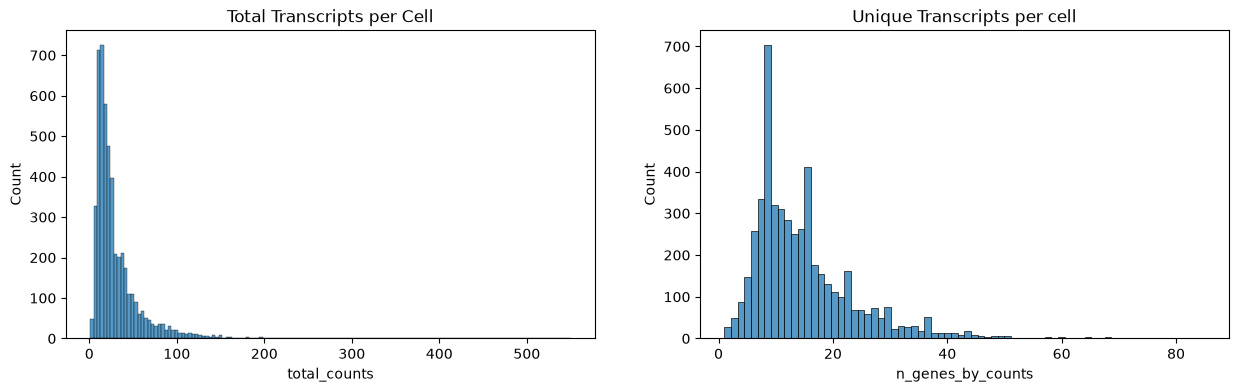

In [11]:
'''Squidpy Processing '''


adata_train = sq.read.vizgen(path = "." ,counts_file = 'counts_train.csv', meta_file = 'meta_train.csv') # reads files from 

sc.pp.calculate_qc_metrics(adata_train, percent_top= None, inplace=True, log1p=True)

fig, (axs1,axs2) = plt.subplots(1,2, figsize=(15,4))
axs1.set_title("Total Transcripts per Cell")
sns.histplot(adata_train.obs["total_counts"],kde = False, ax = axs1)

axs2.set_title("Unique Transcripts per cell")
sns.histplot(adata_train.obs["n_genes_by_counts"],kde = False, ax = axs2)


/tmp/ipykernel_7401/395838934.py:14: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_train,resolution = 0.5) # cluster the cells into subgroups


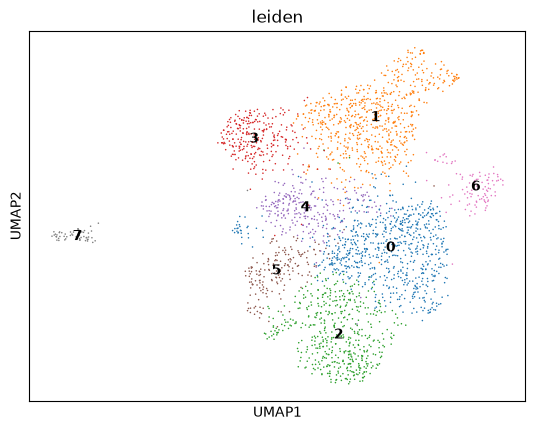

'#neighborhood enrichment analysis: do certain cell types sit next to each other more than randomly \nsq.gr.spatial_neighbors(adata_train, coord_type="generic", spatial_key="spatial2d")\nsq.gr.nhood_enrichment(adata_train, cluster_key="Cell_class")\nsq.pl.nhood_enrichment(\n    adata_train, cluster_key="Cell_class", method="single", cmap="inferno", vmin=-50, vmax=100\n)\n\n# spatial variability of gene expression \n# Uses these statistic methods:  Moran’s I and Geary’s C -> provide a score on the degree of spatial variability of gene expression\n#statistic as well as the p-value are computed for each gene, and false discrovert rate correction is performed.\n\n'

In [13]:
'SCANPY + SQUIDPY MODEL FOR SPATIAL MAPPING'

# fixing up the data 

#filter the cells 
sc.pp.filter_cells(adata_train, min_counts=20) 
# can also use min_genes=200

sc.pp.normalize_total(adata_train,inplace = True) # normalize counts per cell 
sc.pp.log1p(adata_train) # log
sc.pp.pca(adata_train) #pca analysis 
sc.pp.neighbors(adata_train) # computer neighborhood graph 
sc.tl.umap(adata_train) #embed the neighborhood graph of the data 
sc.tl.leiden(adata_train,resolution = 0.5) # cluster the cells into subgroups 

sc.pl.umap(adata_train,color= "leiden",legend_loc='on data',size = 5,wspace = 0.4)



'''#neighborhood enrichment analysis: do certain cell types sit next to each other more than randomly 
sq.gr.spatial_neighbors(adata_train, coord_type="generic", spatial_key="spatial2d")
sq.gr.nhood_enrichment(adata_train, cluster_key="Cell_class")
sq.pl.nhood_enrichment(
    adata_train, cluster_key="Cell_class", method="single", cmap="inferno", vmin=-50, vmax=100
)

# spatial variability of gene expression 
# Uses these statistic methods:  Moran’s I and Geary’s C -> provide a score on the degree of spatial variability of gene expression
#statistic as well as the p-value are computed for each gene, and false discrovert rate correction is performed.

'''

In [ ]:
'GENE EXPRESSION RANKING GRAPP USING LEIDEN -Paulete' 
'''
sc.tl.rank_genes_groups(adata_train, 'leiden', method='wilcoxon') # ranking
sc.pl.rank_genes_groups(adata_train, n_genes=20) # plot ranking
'''

In [15]:
# scVI label transfer 

# reference data 
counts_train_1 = pd.read_csv("counts_train.csv",index_col=0)
meta_train_1= pd.read_csv("meta_train.csv",index_col = 0)

adata_training = ad.AnnData(X=counts_train_1,obs=meta_train_1.loc[counts_train_1.index])

#test data 
counts_test_1 = pd.read_csv("counts_test.csv",index_col=0)
meta_test_1= pd.read_csv("meta_test.csv",index_col = 0)

adata_test = ad.AnnData(X=counts_test_1,obs=meta_test_1.loc[counts_test_1.index])

# concatenate the reference and test data 
concat_adata = ad.concat([adata_test,adata_training])

/usr/local/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/local/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [17]:
# preprocessing data 
concat_adata.layers["counts"] = concat_adata.X.copy() # save a counts layer 



sc.pp.normalize_total(concat_adata,target_sum=1e4) # normalize 
sc.pp.log1p(concat_adata)




In [19]:
# model 
scvi.model.SCVI.setup_anndata(concat_adata,layer = 'counts') #making model 
tmodel = scvi.model.SCVI(concat_adata) #training model
tmodel.train(max_epochs = 250)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/root/venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/root/venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
Epoch 250/250: 100%|██████████| 250/250 [11:30<00:00,  2.76s/it, v_num=1, train_loss=48.1]


<Axes: xlabel='epoch'>

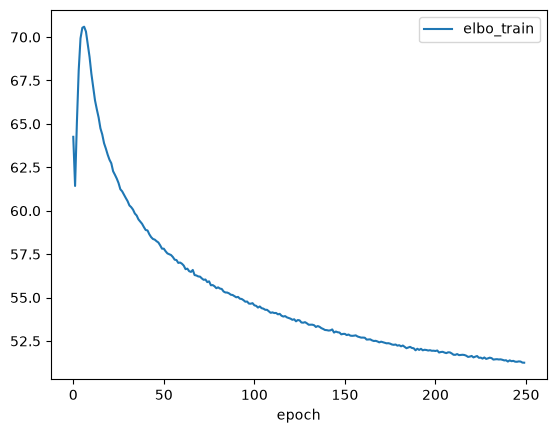

In [21]:
tmodel.history['elbo_train'].plot() # mapping the history of the epoch training model

#can probably decrease epoch to like 200

In [23]:
# convert NaN of testing data to a string 
concat_adata.obs['MERFISH_cell_type_annotation'] = concat_adata.obs['MERFISH_cell_type_annotation'].fillna("Unknown")

In [25]:
# using the scvi model to predict the unknown cells 
learnedmodel = scvi.model.SCANVI.from_scvi_model(tmodel,adata=concat_adata,unlabeled_category='Unknown',labels_key = 'MERFISH_cell_type_annotation')
learnedmodel.train(max_epochs=100,n_samples_per_label = 100)


INFO     Training for 100 epochs.                                                                                  
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/root/venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/root/venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
Epoch 100/100: 100%|██████████| 100/100 [21:26<00:00, 12.86s/it, v_num=1, tra

In [27]:
# Predicted probabilties of the labels for each cell 
softpredictions = learnedmodel.predict(concat_adata,soft= True)
concat_adata.obs["scanvi_confidence"] = softpredictions.max(axis=1).values
concat_adata.obs

,Datasets,volume,center_x,center_y,MERFISH_cell_type_annotation,Region,Excitatory_vs_Inhibitory,Segment,Gender,Mouse_ID,AP_position,Section_ID,_scvi_batch,_scvi_labels,scanvi_confidence
2796212800954100068,20240613,3647.375000,9979.925856,8091.551222,Unknown,1.0,excitatory,2.0,female,F4,1,0613_F4_C,0,60,0.998633
2707604000123100074,20240415,1100.773071,5385.479527,9654.331573,Unknown,NaN,NaN,NaN,male,M3,4,0415_M3_T,0,60,0.808890
2796212800080100088,20240613,3029.895508,7193.083494,550.081350,Unknown,NaN,NaN,NaN,female,F5,3,0613_F5_S,0,60,0.999976
2946331700000000970,20240415,3262.542236,8948.681067,309.374372,Unknown,NaN,NaN,NaN,female,F2,1,0415_F2_C,0,60,0.999980
2796212800882100299,20240613,1551.463623,7788.225136,7682.970213,Unknown,1.0,inhibitory,7.0,female,F3,1,0613_F3_C,0,60,0.956853
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2787889600584100018,20240503,2181.030273,4493.072590,10236.945614,pericyte,NaN,NaN,NaN,male,M4,3,0503_M4_S,0,58,0.998956
2795584800435100084,20240610,3171.459473,866.268481,7194.637866,DH_ex_Sox5/Tac1,1.0,excitatory,5.0,female,F4,1,0610_F4_C,0,16,0.663320
2787445900655100067,20240503,3561.134766,7459.250365,4780.936155,astrocyte_1,NaN,NaN,NaN,female,F3,1,0503_F3_C,0,42,1.000000
2787445900618100152,20240503,4568.070312,7363.552587,4649.108635,oligodendrocyte_2,NaN,NaN,NaN,female,F3,1,0503_F3_C,0,54,0.993289


In [29]:
# Predicted hard labels 
concat_adata.obs['predicted'] = learnedmodel.predict(concat_adata) # adds column of all the predicted cell types
concat_adata = concat_adata[:len(concat_adata)//2]


## Histogram of Confidence Scores 

(array([   9.,   40.,   62.,  117.,  172.,  212.,  252.,  252.,  238.,
         257.,  297.,  292.,  362.,  482., 1956.]),
 array([0.18430297, 0.23868278, 0.29306257, 0.34744239, 0.40182218,
        0.45620197, 0.51058179, 0.56496161, 0.61934137, 0.67372119,
        0.72810102, 0.78248084, 0.8368606 , 0.89124042, 0.94562024,
        1.        ]),
 <BarContainer object of 15 artists>)

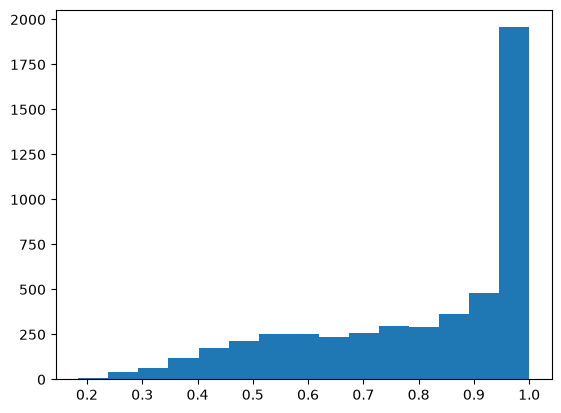

In [31]:
plt.hist(concat_adata.obs["scanvi_confidence"],bins=15)

In [37]:
mean_conf = concat_adata.obs["scanvi_confidence"].mean()
min_conf = concat_adata.obs["scanvi_confidence"].min()
max_conf = concat_adata.obs["scanvi_confidence"].max

print("Mean confidence per cell:", mean_conf)
print("Min confidence per cell:", min_conf)
print("Max confidence per cell:", max_conf)


Mean confidence per cell: 0.80432934
Min confidence per cell: 0.18430297
Max confidence per cell: <bound method Series.max of 2796212800954100068    0.998633
2707604000123100074    0.808890
2796212800080100088    0.999976
2946331700000000970    0.999980
2796212800882100299    0.956853
                         ...   
2787889600409100230    0.339496
2795584800388100027    0.832990
2656143800130100146    0.683639
2707604700272100140    0.861628
2787445900694100124    0.428140
Name: scanvi_confidence, Length: 5000, dtype: float32>


# Final Predictions Upload

In [33]:
# uploading cell id and merfish annotation predicted 
upload = concat_adata.obs['predicted'].reset_index()
upload = upload.rename(columns = {'index':'Cell_ID','predicted':'MERFISH_cell_type_annotation.y'})
upload

,Cell_ID,MERFISH_cell_type_annotation.y
0,2796212800954100068,DM_ex_Zfhx3
1,2707604000123100074,oligodendrocyte_1
2,2796212800080100088,astrocyte_1
3,2946331700000000970,oligodendrocyte_2
4,2796212800882100299,DH_in_Cdh3
...,...,...
4995,2787889600409100230,astrocyte_1
4996,2795584800388100027,endothelial
4997,2656143800130100146,astrocyte_2
4998,2707604700272100140,oligodendrocyte_progenitor_2


In [35]:
upload.to_csv('prediction.csv', index=False)

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=404c9889-fc90-4093-adab-1e9450591cf5' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>